#### Preprocessing code

Code to convert MATLAB processing into Python

Created for dlx56_mPFC_1p_SohalLab repo
based off code in ruleshifting-inscopix private repo

#### Import packages


In [1]:
from __future__ import annotations
import os
from pathlib import Path
from datetime import datetime
from typing import List, Any, Dict
import numpy as np
import pandas as pd
import psutil
from functools import partial
from joblib import Parallel, delayed 
import notebook_setup
info = notebook_setup.setup()
# set up plotting code
import matplotlib as matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
# Apply mplstyle via absolute path from setup info
style_path = Path(info["function_py_storage"]) / "paper_plot.mplstyle"
print(f"Loading style guide at {style_path}")
if style_path.is_file():
    plt.style.use(str(style_path))
else:
    print(f"[warn] Style not found at: {style_path}")
from concurrent.futures import ProcessPoolExecutor, as_completed

Loading style guide at c:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\code\Function .py Storage\paper_plot.mplstyle


In [2]:
#import local yaml for env preset variables
from analysis_config_loader import load_analysis_config  # new import
config_path = "analysis_config.yaml"  # adjust as needed
analysis_config = load_analysis_config(config_path)

In [3]:
type(analysis_config)
analysis_config
stage_names = analysis_config.task_phase_names
stage_cols =  stage_names
stage_names


['Early_IA_Error',
 'Early_IA_Correct',
 'Late_IA',
 'Early_RS_Error',
 'Early_RS_Correct',
 'Late_RS']

#### Define dataset methods

In [4]:
#set parameters
data_type_used = "calcium_spikes" #OR, 'dff'
run_activity_enrichment = True
export_mean_active = True
use_WT_CLNZ_folder = False
phase_type = analysis_config.phase_division_types[1]  # 'complex', early vs late and correct vs error
print(phase_type)
# set up locations for input/output #get where to load data 
root_dir = Path(r'c:\\Users\\13car\\Dropbox\\local_github_repos_personal\\dlx56_mPFC_1p_SohalLab\\code')
print(root_dir)
os.chdir(root_dir)
data_dir = Path(r'c:\\Users\\13car\\Dropbox\\local_github_repos_personal\\dlx56_mPFC_1p_SohalLab\\data')

#make analysis folder 
hour_str = datetime.now().strftime("%H")

storage_folder_name = root_dir / Path(f"processed_{data_type_used}")
print(storage_folder_name)
storage_folder_name.mkdir(parents=True, exist_ok=True)


complex
c:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\code
c:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\code\processed_calcium_spikes


In [5]:
## Matlab file handling functions:
import h5py

def check_corrupted_files(failed_files):
    # Optional Investigate corrupted files
    print("="*70)
    print("INVESTIGATING CORRUPTED FILES")
    print("="*70)

    if len(failed_files) == 0:
        print("No failed files to investigate.")
        return
    
    for fname in failed_files:
        filepath = source_dataset_location / fname
        
        print(f"\n📁 {fname}")
        print("-" * 70)
        
        if not filepath.exists():
            print("   File does not exist!")
            continue
        
        # Check file size
        size_bytes = filepath.stat().st_size
        size_kb = size_bytes / 1024
        size_mb = size_kb / 1024
        
        print(f"  Size: {size_bytes:,} bytes ({size_mb:.2f} MB)")
        
        # Read first bytes to check file signature
        with open(filepath, 'rb') as f:
            header = f.read(100)
        
        # Check for MATLAB file signatures
        print(f"  First 20 bytes (hex): {header[:20].hex()}")
        
        # HDF5 files should start with \x89HDF\r\n\x1a\n
        if header[:4] == b'\x89HDF':
            print("  ✓ Valid HDF5 signature")
        elif header[:4] == b'MATL':
            print("  ⚠️ Old MATLAB format (v5/v6) - needs scipy.io")
        else:
            print(f"   Unknown file signature - file may be corrupted")
            print(f"     Expected: b'\\x89HDF' or b'MATL'")
            print(f"     Got: {header[:4]}")
        
        # Try to detect if file is truncated
        if size_mb < 1:
            print(f"  ⚠️ WARNING: File is unusually small ({size_mb:.2f} MB)")

    # Compare with a working file
    print("\n" + "="*70)
    print("COMPARISON WITH WORKING FILES:")

    # Get file sizes of all working files
    working_sizes = []
    for obj in loaded_objects[:5]:
        fname = obj['name'] + '_dataset_object.mat'
        fpath = source_dataset_location / fname
        if fpath.exists():
            size_mb = fpath.stat().st_size / 1024 / 1024
            working_sizes.append(size_mb)
            print(f"  {fname}: {size_mb:.2f} MB")

    if working_sizes:
        avg_size = sum(working_sizes) / len(working_sizes)
        print(f"\n  Average working file size: {avg_size:.2f} MB")

def load_matlab_object(filepath):
    """Load MATLAB dataset_with_spatial_ROI object from .mat file"""
    # Parse metadata from filename
    filename = filepath.stem.replace('_dataset_object', '')
    parts = filename.split('_')
    
    # Extract name, geno from filename (e.g., "10_3_HET_RS1")
    name = filename
    if len(parts) >= 3:
        geno = parts[2]  # HET or WT
        session = parts[3] if len(parts) > 3 else 'RS1'
    else:
        geno = "UNKNOWN"
        session = "RS1"
    
    try:
        with h5py.File(filepath, 'r') as f:            # Load numeric data from known datasets
            raster = f['#refs#']['i'][()]  # (time, cells)
            # Get deduplicated flag from group x
            deduplicated = f['#refs#']['x']['deduplicated'][0, 0] if 'deduplicated' in f['#refs#']['x'] else False
            # Create object dictionary
            obj = {
                'name': name,
                'geno': geno,
                'session': session,
                'geno_day': None,  # Will need to be set externally if needed
                'raster': raster.T,  # Transpose to (cells, time)
                'deduplicated': bool(deduplicated),
                'good_cells': f['#refs#']['k'][()] if 'k' in f['#refs#'] else None,  # Cell IDs
                'labels': f['#refs#']['j'][()] if 'j' in f['#refs#'] else None,  # Trial/time info
            }
            # Load spatial info if present
            if 'n' in f['#refs#']:
                spatial = f['#refs#']['n']
                obj['spatial_weights'] = spatial['spatial_weights'][()] if 'spatial_weights' in spatial else None
                obj['temporal_weights'] = spatial['temporal_weights'][()] if 'temporal_weights' in spatial else None
                obj['user_labels'] = spatial['user_labels'][()] if 'user_labels' in spatial else None
                obj['subject_name'] = spatial['subject_name'][()] if 'subject_name' in spatial else None
            
            return obj
    
    except (OSError, KeyError) as e:
        print(f"  ERROR loading {filepath.name}: {e}")
        return None


In [6]:
#get all dataset names
#verify you are using the correct number of dataset 
source_dataset_location = Path(r"C:\Users\13car\Dropbox\UCSF\vikaas\Ruleshifting task notes\dlx mice notes\All datasets- Padded Labels, raster, EXTRACT outputs\dataset_objects")
content_names = [f for f in source_dataset_location.glob('**/*') if "object" in f.name]
print(f"Found {len(content_names)} files in {source_dataset_location}")
for file in content_names:
    print(file.name)

assert len(content_names) == 35, "Number of datasets does not match expected"

Found 35 files in C:\Users\13car\Dropbox\UCSF\vikaas\Ruleshifting task notes\dlx mice notes\All datasets- Padded Labels, raster, EXTRACT outputs\dataset_objects
10_3_HET_RS1_dataset_object.mat
10_3_HET_RS2_dataset_object.mat
10_3_HET_RS3_dataset_object.mat
13_3_HET_RS1_dataset_object.mat
13_3_HET_RS2_dataset_object.mat
13_3_HET_RS3_dataset_object.mat
13_4_WT_RS1_dataset_object.mat
13_4_WT_RS2_dataset_object.mat
13_5_HET_RS1_dataset_object.mat
13_5_HET_RS2_dataset_object.mat
13_5_HET_RS3_dataset_object.mat
13_6_WT_RS1_dataset_object.mat
13_6_WT_RS2_dataset_object.mat
13_8_HET_RS1_dataset_object.mat
13_8_HET_RS2_dataset_object.mat
13_8_HET_RS3_dataset_object.mat
14_2_WT_RS1_dataset_object.mat
14_2_WT_RS2_dataset_object.mat
15_1_HET_RS1_dataset_object.mat
15_1_HET_RS2_dataset_object.mat
15_1_HET_RS3_dataset_object.mat
5_3_WT_RS1_dataset_object.mat
5_3_WT_RS2_dataset_object.mat
6_2_WT_RS1_dataset_object.mat
6_2_WT_RS2_dataset_object.mat
7_2_WT_RS1_dataset_object.mat
7_4_WT_RS1_dataset_obje

In [7]:
# Load all files with error handling
loaded_objects = []
failed_files = []

for num, file in enumerate(content_names):
    print(f"Loading file {num}/{len(content_names)}: {file.name}")
    obj = load_matlab_object(file)
    if obj is None:
        failed_files.append(file.name)
        print(f"  SKIPPED\n")
        continue
    loaded_objects.append(obj)
    print(f"  {obj['name']}: {obj['raster'].shape[0]} cells × {obj['raster'].shape[1]} frames")
print(f"\n SUMMARY: Successfully loaded {len(loaded_objects)}/{len(content_names)} files")

if failed_files:
    print(f"\n Failed files ({len(failed_files)}):")
    for fname in failed_files:
        print(f"  - {fname}")
check_corrupted_files(failed_files)

Loading file 0/35: 10_3_HET_RS1_dataset_object.mat
  10_3_HET_RS1: 136 cells × 150415 frames
Loading file 1/35: 10_3_HET_RS2_dataset_object.mat
  10_3_HET_RS2: 168 cells × 97940 frames
Loading file 2/35: 10_3_HET_RS3_dataset_object.mat
  10_3_HET_RS3: 157 cells × 108794 frames
Loading file 3/35: 13_3_HET_RS1_dataset_object.mat
  13_3_HET_RS1: 160 cells × 191533 frames
Loading file 4/35: 13_3_HET_RS2_dataset_object.mat
  13_3_HET_RS2: 145 cells × 108651 frames
Loading file 5/35: 13_3_HET_RS3_dataset_object.mat
  13_3_HET_RS3: 147 cells × 128277 frames
Loading file 6/35: 13_4_WT_RS1_dataset_object.mat
  13_4_WT_RS1: 183 cells × 153831 frames
Loading file 7/35: 13_4_WT_RS2_dataset_object.mat
  13_4_WT_RS2: 171 cells × 106245 frames
Loading file 8/35: 13_5_HET_RS1_dataset_object.mat
  13_5_HET_RS1: 120 cells × 229350 frames
Loading file 9/35: 13_5_HET_RS2_dataset_object.mat
  13_5_HET_RS2: 125 cells × 141283 frames
Loading file 10/35: 13_5_HET_RS3_dataset_object.mat
  13_5_HET_RS3: 131 cel

#### study object info

In [8]:
obj.keys()

dict_keys(['name', 'geno', 'session', 'geno_day', 'raster', 'deduplicated', 'good_cells', 'labels', 'spatial_weights', 'temporal_weights', 'user_labels', 'subject_name'])

In [9]:
len(obj['user_labels'])

329

In [10]:
for obj in loaded_objects:
    print(f"  {obj['name']}: Good cells: {len(obj['good_cells'])}, raster shape: {obj['raster'].shape[0]}  × {obj['raster'].shape[1]}")

  10_3_HET_RS1: Good cells: 136, raster shape: 136  × 150415
  10_3_HET_RS2: Good cells: 168, raster shape: 168  × 97940
  10_3_HET_RS3: Good cells: 157, raster shape: 157  × 108794
  13_3_HET_RS1: Good cells: 160, raster shape: 160  × 191533
  13_3_HET_RS2: Good cells: 145, raster shape: 145  × 108651
  13_3_HET_RS3: Good cells: 147, raster shape: 147  × 128277
  13_4_WT_RS1: Good cells: 183, raster shape: 183  × 153831
  13_4_WT_RS2: Good cells: 171, raster shape: 171  × 106245
  13_5_HET_RS1: Good cells: 120, raster shape: 120  × 229350
  13_5_HET_RS2: Good cells: 125, raster shape: 125  × 141283
  13_5_HET_RS3: Good cells: 131, raster shape: 131  × 96995
  13_6_WT_RS1: Good cells: 247, raster shape: 247  × 206081
  13_6_WT_RS2: Good cells: 246, raster shape: 246  × 145514
  13_8_HET_RS1: Good cells: 207, raster shape: 207  × 124098
  13_8_HET_RS2: Good cells: 206, raster shape: 206  × 111694
  13_8_HET_RS3: Good cells: 244, raster shape: 244  × 126723
  14_2_WT_RS1: Good cells: 186

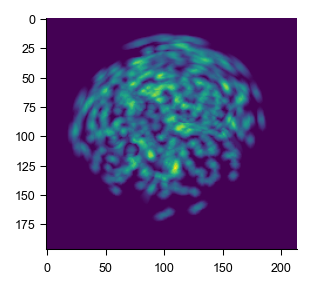

In [11]:
fig,ax = plt.subplots(figsize = (3,2))
plt.imshow(np.mean(obj['spatial_weights'], axis=0))

####  Get post-outcome time-series directly

In [27]:
canon_timeseries_path = Path(r"C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\data\single_trial_post_neuron_timeseries_w_enrichment_11-Dec-2024_.csv")
canon_timeseries = pd.read_csv(canon_timeseries_path)
canon_timeseries

,Unnamed: 0,task_phase_vec,IA_RS_vec,corr_err_vec,trial_num,neuron_ID,name,day,geno,geno_day,...,Early_IA_Error,Early_IA_Correct,Late_IA,Early_RS_Error,Early_RS_Correct,Late_RS,enriched_in_phase,any_enrichment,unique_ID,max_trial_val
0,0,Early_IA_Correct,IA,Correct,1,1,10_3_HET_RS1,1,HET,Het VEH,...,1.0,0.0,0.0,0.0,0.0,0.0,False,1.0,10_3_HET_RS1-1,1.0
1,2,Early_IA_Correct,IA,Correct,1,3,10_3_HET_RS1,1,HET,Het VEH,...,1.0,0.0,0.0,0.0,0.0,0.0,False,1.0,10_3_HET_RS1-3,1.0
2,3,Early_IA_Correct,IA,Correct,1,4,10_3_HET_RS1,1,HET,Het VEH,...,0.0,0.0,0.0,1.0,0.0,0.0,False,1.0,10_3_HET_RS1-4,1.0
3,4,Early_IA_Correct,IA,Correct,1,5,10_3_HET_RS1,1,HET,Het VEH,...,0.0,0.0,0.0,0.0,0.0,0.0,False,0.0,10_3_HET_RS1-5,1.0
4,5,Early_IA_Correct,IA,Correct,1,6,10_3_HET_RS1,1,HET,Het VEH,...,0.0,0.0,0.0,0.0,0.0,0.0,False,0.0,10_3_HET_RS1-6,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
93248,116370,Late_RS,RS,Correct,38,209,9_3_HET_RS3,3,HET,Het postCLNZ,...,1.0,0.0,0.0,0.0,0.0,0.0,False,1.0,9_3_HET_RS3-209,1.0
93249,116373,Late_RS,RS,Correct,38,212,9_3_HET_RS3,3,HET,Het postCLNZ,...,1.0,0.0,0.0,1.0,0.0,0.0,False,2.0,9_3_HET_RS3-212,1.0
93250,116374,Late_RS,RS,Correct,38,213,9_3_HET_RS3,3,HET,Het postCLNZ,...,0.0,0.0,0.0,0.0,0.0,0.0,False,0.0,9_3_HET_RS3-213,1.0
93251,116375,Late_RS,RS,Correct,38,214,9_3_HET_RS3,3,HET,Het postCLNZ,...,0.0,0.0,0.0,0.0,0.0,1.0,True,1.0,9_3_HET_RS3-214,1.0


In [28]:
print(canon_timeseries.groupby(by = 'geno_day')['unique_ID'].nunique())
print(f" Canon timeseries before processing unique cells: {canon_timeseries['unique_ID'].nunique()}")

geno_day
Het CLNZ         866
Het VEH          874
Het postCLNZ     937
WT CLNZ         1019
WT VEH          1080
Name: unique_ID, dtype: int64
 Canon timeseries before processing unique cells: 4776


#### Import canonical dataset used in paper

In [12]:
# import canonical ensemble matrix previously created in MATLAB, used for paper #find old file- 
canonical_file = Path(r"C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\data\Dlx56_Normalized Trial Calcium Timeseries_20_Jun_2025.parquet")
canonical_data = pd.read_parquet(canonical_file)
print(canonical_data.info())
canonical_data.head(3)

<class 'pandas.core.frame.DataFrame'>
Index: 93253 entries, 0 to 116376
Data columns (total 93 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   task_phase_vec     93253 non-null  object 
 1   IA_RS_vec          93253 non-null  object 
 2   corr_err_vec       93253 non-null  object 
 3   trial_num          93253 non-null  int64  
 4   neuron_ID          93253 non-null  int64  
 5   name               93253 non-null  object 
 6   day                93253 non-null  int32  
 7   geno               93253 non-null  object 
 8   geno_day           93253 non-null  object 
 9   -3.0s to -2.75s    93253 non-null  float64
 10  -2.75s to -2.5s    93253 non-null  float64
 11  -2.5s to -2.25s    93253 non-null  float64
 12  -2.25s to -2.0s    93253 non-null  float64
 13  -2.0s to -1.75s    93253 non-null  float64
 14  -1.75s to -1.5s    93253 non-null  float64
 15  -1.5s to -1.25s    93253 non-null  float64
 16  -1.25s to -1.0s    93253 n

,task_phase_vec,IA_RS_vec,corr_err_vec,trial_num,neuron_ID,name,day,geno,geno_day,-3.0s to -2.75s,...,Late_IA,Early_RS_Error,Early_RS_Correct,Late_RS,enriched_in_phase,any_enrichment,unique_ID,max_trial_val,mean_rate,active_in_trial
0,Early_IA_Correct,IA,Correct,1,1,10_3_HET_RS1,1,HET,Het VEH,0.0,...,0.0,0.0,0.0,0.0,False,1.0,10_3_HET_RS1-1,1.0,0.0,False
2,Early_IA_Correct,IA,Correct,1,3,10_3_HET_RS1,1,HET,Het VEH,0.0,...,0.0,0.0,0.0,0.0,False,1.0,10_3_HET_RS1-3,1.0,0.0,False
3,Early_IA_Correct,IA,Correct,1,4,10_3_HET_RS1,1,HET,Het VEH,0.0,...,0.0,1.0,0.0,0.0,False,1.0,10_3_HET_RS1-4,1.0,0.0,False


In [13]:
#get ensemble info from canon df
canon_ensembles  = canonical_data.groupby(by = ['unique_ID', 'geno', 'geno_day'])[stage_cols].first()
canon_ensembles.tail(3)

,,,Early_IA_Error,Early_IA_Correct,Late_IA,Early_RS_Error,Early_RS_Correct,Late_RS
unique_ID,geno,geno_day,,,,,,
9_3_HET_RS3-97,HET,Het postCLNZ,1.0,0.0,0.0,0.0,0.0,0.0
9_3_HET_RS3-98,HET,Het postCLNZ,0.0,0.0,0.0,0.0,0.0,0.0
9_3_HET_RS3-99,HET,Het postCLNZ,0.0,0.0,0.0,0.0,0.0,0.0


#### import base matlab TACO

In [53]:
canon_taco = Path(r"c:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\data\main_datasets_complexTACO- neurons_activity by task phase_10-Dec-2024.xls")
canon_taco = pd.read_excel(canon_taco)
canon_taco.head(3)

,pre_outcome_Early_IA_Error,pre_outcome_Early_IA_Correct,pre_outcome_Late_IA,pre_outcome_Early_RS_Error,pre_outcome_Early_RS_Correct,pre_outcome_Late_RS,post_outcome_Early_IA_Error,post_outcome_Early_IA_Correct,post_outcome_Late_IA,post_outcome_Early_RS_Error,...,geno_day,geno,neuron_ID,peak_dff_threshold_percentile,Var1_1,Var1_2,Var1_3,Var1_4,Var1_5,Var1_6
0,0,0,0,0,0,0,1,0,0,0,...,HET RS1,HET,1,1,10-Dec-2024 15:20:19,500,95,False,bimodality,1
1,0,0,0,0,0,0,0,0,0,0,...,HET RS1,HET,2,1,10-Dec-2024 15:20:19,500,95,False,bimodality,1
2,0,0,0,0,0,0,1,0,0,0,...,HET RS1,HET,3,1,10-Dec-2024 15:20:19,500,95,False,bimodality,1


In [54]:
frame_cols = [c for c in canon_taco.columns if 'f_' in c]
non_frame_cols = [c for c in canon_taco.columns if 'f_' not in c]
non_frame_cols

['pre_outcome_Early_IA_Error',
 'pre_outcome_Early_IA_Correct',
 'pre_outcome_Late_IA',
 'pre_outcome_Early_RS_Error',
 'pre_outcome_Early_RS_Correct',
 'pre_outcome_Late_RS',
 'post_outcome_Early_IA_Error',
 'post_outcome_Early_IA_Correct',
 'post_outcome_Late_IA',
 'post_outcome_Early_RS_Error',
 'post_outcome_Early_RS_Correct',
 'post_outcome_Late_RS',
 'ITI_Early_IA_Error',
 'ITI_Early_IA_Correct',
 'ITI_Late_IA',
 'ITI_Early_RS_Error',
 'ITI_Early_RS_Correct',
 'ITI_Late_RS',
 'baseline_sig_cells',
 'name',
 'geno_day',
 'geno',
 'neuron_ID',
 'Var1_1',
 'Var1_2',
 'Var1_3',
 'Var1_4',
 'Var1_5',
 'Var1_6']

In [55]:
canon_taco.groupby(by = 'name')['neuron_ID'].nunique().sum()

5961

In [66]:
canon_post_taco = canon_taco[ ['post_outcome_Early_IA_Error','post_outcome_Early_IA_Correct','post_outcome_Late_IA',
 'post_outcome_Early_RS_Error', 'post_outcome_Early_RS_Correct','post_outcome_Late_RS', 'name','geno_day','geno','neuron_ID']].copy()
canon_post_taco.rename({old:old.replace("post_outcome_","") for old in ['post_outcome_Early_IA_Error','post_outcome_Early_IA_Correct','post_outcome_Late_IA',
                                                                       'post_outcome_Early_RS_Error','post_outcome_Early_RS_Correct','post_outcome_Late_RS']},
                                                                       axis=1, inplace=True)
canon_post_taco['unique_ID'] = canon_post_taco['name'].str.cat(canon_post_taco['neuron_ID'].astype(str), sep="-")

In [67]:
canon_post_taco

,Early_IA_Error,Early_IA_Correct,Late_IA,Early_RS_Error,Early_RS_Correct,Late_RS,name,geno_day,geno,neuron_ID,unique_ID
0,1,0,0,0,0,0,10_3_HET_RS1,HET RS1,HET,1,10_3_HET_RS1-1
1,0,0,0,0,0,0,10_3_HET_RS1,HET RS1,HET,2,10_3_HET_RS1-2
2,1,0,0,0,0,0,10_3_HET_RS1,HET RS1,HET,3,10_3_HET_RS1-3
3,0,0,0,1,0,0,10_3_HET_RS1,HET RS1,HET,4,10_3_HET_RS1-4
4,0,0,0,0,0,0,10_3_HET_RS1,HET RS1,HET,5,10_3_HET_RS1-5
...,...,...,...,...,...,...,...,...,...,...,...
5956,0,0,0,0,0,0,9_3_HET_RS3,HET RS3,HET,211,9_3_HET_RS3-211
5957,1,0,0,1,0,0,9_3_HET_RS3,HET RS3,HET,212,9_3_HET_RS3-212
5958,0,0,0,0,0,0,9_3_HET_RS3,HET RS3,HET,213,9_3_HET_RS3-213
5959,0,0,0,0,0,1,9_3_HET_RS3,HET RS3,HET,214,9_3_HET_RS3-214


### Extract and Transform Matlab Objects into stage-labeled dataframes

#### E- dataset objs to dataframes, T- add task stage cols

In [14]:
def dataset_obj_to_df(dataset_obj):
    # Create DataFrame from raster (cells × frames)
    print(f"Processing {dataset_obj['name']}: {dataset_obj['raster'].nbytes} bytes")
    #setup dataset df 
    raster_df = pd.DataFrame(
        dataset_obj['raster'].T,
        index=[f'frame_{i}' for i in range(dataset_obj['raster'].shape[1])],
        columns = [f'cell_{i+1}' for i in range(dataset_obj['raster'].shape[0])],
        dtype = 'Sparse[int]')
            #add labels
    raster_df['labels'] = dataset_obj['labels']
    # Add metadata columns
    #cell Id is represented as col name 
    raster_df['subject_name'] = dataset_obj['name']
    raster_df['geno'] = dataset_obj['geno']
    raster_df['session'] = dataset_obj['session']
    
    return raster_df
#test 1 dataset
test_df = dataset_obj_to_df(loaded_objects[0])
print(test_df.info())
test_df.tail(3)

Processing 10_3_HET_RS1: 163651520 bytes
<class 'pandas.core.frame.DataFrame'>
Index: 150415 entries, frame_0 to frame_150414
Columns: 140 entries, cell_1 to session
dtypes: Sparse[int32, 0](136), float64(1), object(3)
memory usage: 12.5+ MB
None


,cell_1,cell_2,cell_3,cell_4,cell_5,cell_6,cell_7,cell_8,cell_9,cell_10,...,cell_131,cell_132,cell_133,cell_134,cell_135,cell_136,labels,subject_name,geno,session
frame_150412,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,15.0,10_3_HET_RS1,HET,RS1
frame_150413,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,15.0,10_3_HET_RS1,HET,RS1
frame_150414,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,15.0,10_3_HET_RS1,HET,RS1


In [15]:
from trial_detection import return_trial_num_at_frame, build_phase_masks, get_trial_stage_map, get_inRS_isError

def add_task_stage_to_raster_df(raster_df, analysis_config):
    """ Joins all the trial stage functions into one function for ease of use (function imported elsewhere).2s per raster 
    #workflow: 
        # 1) Call "trial num at frame" function
        # 2. Add trial number to raster_df
        # 3. drop frames that are not in a trial
        # 4. Add task stage to raster_df based off trial number at frame
    """
    stage_names = analysis_config.task_phase_names
    # 1. Transform frame label vector into trial vector
    labels = raster_df['labels']
    trial_num_at_frame, _, num_trials = return_trial_num_at_frame(labels)
    raster_df.loc[:, 'trial_num'] = trial_num_at_frame 

    # 2. Add trial number to raster_df
    raster_df = raster_df[raster_df['trial_num'] > 0].copy() #  dropping trial_num == 0
    # 4. Add task stage to raster_df based off trial number at frame
    stage_dict = build_phase_masks(labels,analysis_config)
    #5. map trial num to stage
    trial_stage_map = get_trial_stage_map(stage_dict, stage_names, num_trials)
    raster_df.loc[:, 'task_stage'] = raster_df['trial_num'].map(trial_stage_map)
    return raster_df

In [16]:
def label_frame_sections_df(df: pd.DataFrame, label_col: str,*, section_names=("pre_outcome", "post_outcome", "ITI")):
    """
    Vectorized: assign each frame one of {pre_outcome, post_outcome, ITI}. Tie-breaks at 4 (IA) and 11 (RS) go to post_outcome (overwrite order).

    Parameters
    ----------
    df : DataFrame with one row per frame
    label_col : name of column holding per-frame integer labels
    section_names : (pre_outcome, post_outcome, ITI)

    Returns
    -------
    pd.Series (object) of section names aligned to df.index
    """
    pre_outcome, post_outcome, iti = section_names
    labels = df[label_col].to_numpy()
    out = np.full(labels.shape[0], None, dtype=object)

    # IA ranges (2–8)
    ia_pre  = (labels >= 2)  & (labels <= 4)     # pre_outcome
    ia_post = (labels >= 4)  & (labels <= 7)     # post_outcome (overwrites label==4)
    ia_iti  = (labels == 8)                      # ITI

    # RS ranges (9–15)
    rs_pre  = (labels >= 9)  & (labels <= 11)    # pre_outcome
    rs_post = (labels >= 11) & (labels <= 14)    # post_outcome (overwrites label==11)
    rs_iti  = (labels == 15)                     # ITI

    # Overwrite order preserves “boundary goes to later section”:
    out[ia_pre  | rs_pre]  = pre_outcome
    out[ia_post | rs_post] = post_outcome
    out[ia_iti  | rs_iti]  = iti

    return out

In [17]:
# Loop over imported subject rasters and create pandas DataFrames
raster_dataframes = {}

for obj in loaded_objects:    # Create DataFrame from raster (cells × frames)
    raster_df = dataset_obj_to_df(obj)
    raster_df = add_task_stage_to_raster_df(raster_df, analysis_config)
    raster_df['trial_section'] = label_frame_sections_df(raster_df, 'labels', section_names=analysis_config.trial_section_names) #annotate pre,post,ITI

    raster_dataframes[obj['name']] = raster_df
print(f"\nTotal DataFrames created: {len(raster_dataframes)}")

Processing 10_3_HET_RS1: 163651520 bytes
Processing 10_3_HET_RS2: 131631360 bytes
Processing 10_3_HET_RS3: 136645264 bytes
Processing 13_3_HET_RS1: 245162240 bytes
Processing 13_3_HET_RS2: 126035160 bytes
Processing 13_3_HET_RS3: 150853752 bytes
Processing 13_4_WT_RS1: 225208584 bytes
Processing 13_4_WT_RS2: 145343160 bytes
Processing 13_5_HET_RS1: 220176000 bytes
Processing 13_5_HET_RS2: 141283000 bytes
Processing 13_5_HET_RS3: 101650760 bytes
Processing 13_6_WT_RS1: 407216056 bytes
Processing 13_6_WT_RS2: 286371552 bytes
Processing 13_8_HET_RS1: 205506288 bytes
Processing 13_8_HET_RS2: 184071712 bytes
Processing 13_8_HET_RS3: 247363296 bytes
Processing 14_2_WT_RS1: 158077680 bytes
Processing 14_2_WT_RS2: 170570944 bytes
Processing 15_1_HET_RS1: 209435040 bytes
Processing 15_1_HET_RS2: 185898360 bytes
Processing 15_1_HET_RS3: 133253480 bytes
Processing 5_3_WT_RS1: 198030360 bytes
Processing 5_3_WT_RS2: 211466640 bytes
Processing 6_2_WT_RS1: 212864136 bytes
Processing 6_2_WT_RS2: 19240

#### Find post-outcome activity in all raster Dfs

In [37]:
# Loop through all subjects and compute sum of activity in post_outcome period
post_outcome_activity = []

for subject_name, raster_df in raster_dataframes.items():
    print(f"Processing {subject_name}...")
    
    # Get cell columns
    cell_col = [c for c in raster_df.columns if 'cell' in c]
    
    # Filter for post_outcome frames
    post_outcome_mask = raster_df['trial_section'] == 'post_outcome'
    post_outcome_frames = raster_df[post_outcome_mask]
    
    # Sum activity across all post_outcome frames for each cell
    activity_sum = post_outcome_frames[cell_col].sum()
    
    # Add subject info and store
    activity_sum['subject_name'] = subject_name
    activity_sum['n_frames'] = post_outcome_mask.sum()
    
    post_outcome_activity.append(activity_sum)

# Combine into a single DataFrame
post_outcome_df = pd.DataFrame(post_outcome_activity)

# Reorder columns to put metadata first
metadata_cols = ['subject_name', 'n_frames']
cell_cols = [c for c in post_outcome_df.columns if c.startswith('cell_')]
post_outcome_df = post_outcome_df[metadata_cols + cell_cols]

print(f"\nCompleted! Shape: {post_outcome_df.shape}")
post_outcome_df.head()

Processing 10_3_HET_RS1...
Processing 10_3_HET_RS2...
Processing 10_3_HET_RS3...
Processing 13_3_HET_RS1...
Processing 13_3_HET_RS2...
Processing 13_3_HET_RS3...
Processing 13_4_WT_RS1...
Processing 13_4_WT_RS2...
Processing 13_5_HET_RS1...
Processing 13_5_HET_RS2...
Processing 13_5_HET_RS3...
Processing 13_6_WT_RS1...
Processing 13_6_WT_RS2...
Processing 13_8_HET_RS1...
Processing 13_8_HET_RS2...
Processing 13_8_HET_RS3...
Processing 14_2_WT_RS1...
Processing 14_2_WT_RS2...
Processing 15_1_HET_RS1...
Processing 15_1_HET_RS2...
Processing 15_1_HET_RS3...
Processing 5_3_WT_RS1...
Processing 5_3_WT_RS2...
Processing 6_2_WT_RS1...
Processing 6_2_WT_RS2...
Processing 7_2_WT_RS1...
Processing 7_4_WT_RS1...
Processing 7_5_WT_RS1...
Processing 7_5_WT_RS2...
Processing 7_6_HET_RS1...
Processing 7_6_HET_RS2...
Processing 7_6_HET_RS3...
Processing 9_3_HET_RS1...
Processing 9_3_HET_RS2...
Processing 9_3_HET_RS3...

Completed! Shape: (35, 249)


,subject_name,n_frames,cell_1,cell_2,cell_3,cell_4,cell_5,cell_6,cell_7,cell_8,...,cell_238,cell_239,cell_240,cell_241,cell_242,cell_243,cell_244,cell_245,cell_246,cell_247
0,10_3_HET_RS1,37300,2166,424,2287,3424,3270,1895,205,302,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,10_3_HET_RS2,23160,449,485,1033,818,3210,475,322,629,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,10_3_HET_RS3,18460,874,5051,3713,555,642,1979,3280,471,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,13_3_HET_RS1,46740,3021,3726,1365,16090,697,799,318,2337,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,13_3_HET_RS2,26960,146,1181,1143,1384,230,273,582,96,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [38]:
# Find number of cells with zero activity by subject

zero_counts = post_outcome_df.set_index('subject_name')[cell_cols].apply(
    lambda row: (row == 0).sum(), axis=1
).reset_index()
zero_counts.columns = ['subject_name', 'n_zero_cells']

zero_counts['n_total_cells'] = post_outcome_df[cell_cols].notna().sum(axis=1).values
zero_counts['pct_zero'] = (zero_counts['n_zero_cells'] / zero_counts['n_total_cells']) * 100

zero_counts

,subject_name,n_zero_cells,n_total_cells,pct_zero
0,10_3_HET_RS1,0,136,0.000000
1,10_3_HET_RS2,2,168,1.190476
2,10_3_HET_RS3,8,157,5.095541
3,13_3_HET_RS1,4,160,2.500000
4,13_3_HET_RS2,12,145,8.275862
5,13_3_HET_RS3,1,147,0.680272
6,13_4_WT_RS1,6,183,3.278689
7,13_4_WT_RS2,2,171,1.169591
8,13_5_HET_RS1,0,120,0.000000
9,13_5_HET_RS2,0,125,0.000000


In [39]:
zero_counts.sum()

subject_name     10_3_HET_RS110_3_HET_RS210_3_HET_RS313_3_HET_R...
n_zero_cells                                                   300
n_total_cells                                                 5961
pct_zero                                                179.475441
dtype: object

<Axes: >

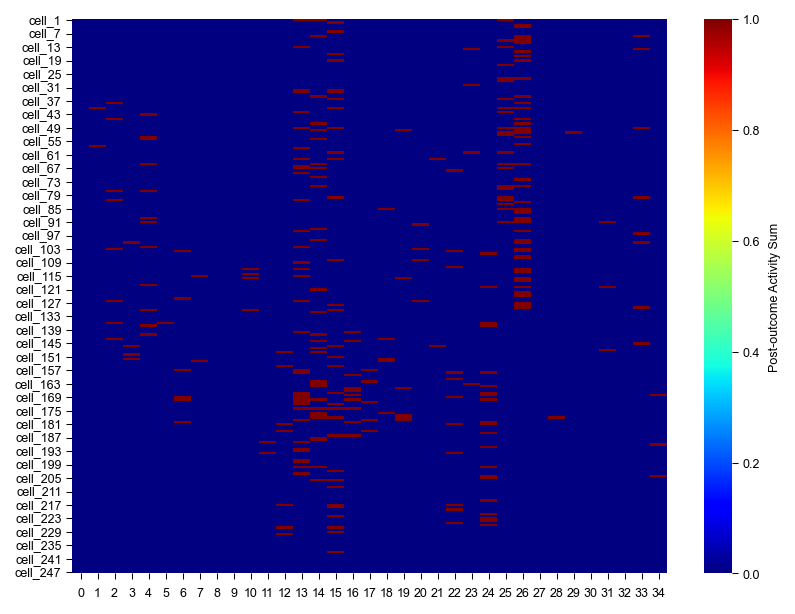

In [33]:
sns.heatmap(post_outcome_df[cell_cols].T == 0, cmap='jet', cbar_kws={'label': 'Post-outcome Activity Sum'})

#### T- add task stage + metadata to subject dfs

In [18]:
raster_df

,cell_1,cell_2,cell_3,cell_4,cell_5,cell_6,cell_7,cell_8,cell_9,cell_10,...,cell_213,cell_214,cell_215,labels,subject_name,geno,session,trial_num,task_stage,trial_section
frame_15007,0,1,0,0,1,0,0,0,0,0,...,0,0,1,2.0,9_3_HET_RS3,HET,RS3,1,Early_IA_Correct,pre_outcome
frame_15008,0,1,0,0,1,0,0,0,0,0,...,0,0,1,2.0,9_3_HET_RS3,HET,RS3,1,Early_IA_Correct,pre_outcome
frame_15009,0,1,0,0,1,0,0,0,0,0,...,0,0,1,2.0,9_3_HET_RS3,HET,RS3,1,Early_IA_Correct,pre_outcome
frame_15010,0,1,0,0,1,0,0,0,0,0,...,0,0,1,2.0,9_3_HET_RS3,HET,RS3,1,Early_IA_Correct,pre_outcome
frame_15011,0,1,0,0,1,0,0,0,0,0,...,0,0,1,2.0,9_3_HET_RS3,HET,RS3,1,Early_IA_Correct,pre_outcome
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
frame_205895,0,0,0,0,0,0,0,0,0,0,...,0,0,0,15.0,9_3_HET_RS3,HET,RS3,38,Late_RS,ITI
frame_205896,0,0,0,0,0,0,0,0,0,0,...,0,0,0,15.0,9_3_HET_RS3,HET,RS3,38,Late_RS,ITI
frame_205897,0,0,0,0,0,0,0,0,0,0,...,0,0,0,15.0,9_3_HET_RS3,HET,RS3,38,Late_RS,ITI
frame_205898,0,0,0,0,0,0,0,0,0,0,...,0,0,0,15.0,9_3_HET_RS3,HET,RS3,38,Late_RS,ITI


In [19]:
def plot_task_stages(stage_dict, stage_cols, fig_size = (10, 7)):
    # Define stage_cols from the stage_dict keys (excluding internal keys starting with '_')
    stage_cols = [k for k in stage_dict.keys() if not k.startswith('_')]
    # Fix variable name: use 'axes' consistently, and squeeze data to handle shape (38,1) -> (38,)
    fig, axes = plt.subplots(len(stage_cols), 1, figsize = fig_size, layout = 'constrained')
    for index, s in enumerate(stage_cols):
        # Reshape to column vector for proper heatmap display
        data =  stage_dict[s].reshape(1, -1)
        sns.heatmap(ax = axes[index], data = data, cbar = False,  cmap = 'viridis')
        axes[index].set_title(s)



In [20]:

print(raster_df.trial_section.unique())
print(raster_df.task_stage.unique())
raster_df

['pre_outcome' 'post_outcome' 'ITI' None]
['Early_IA_Correct' 'Early_IA_Error' 0 'Late_IA' 'Early_RS_Correct'
 'Early_RS_Error' 'Late_RS']


,cell_1,cell_2,cell_3,cell_4,cell_5,cell_6,cell_7,cell_8,cell_9,cell_10,...,cell_213,cell_214,cell_215,labels,subject_name,geno,session,trial_num,task_stage,trial_section
frame_15007,0,1,0,0,1,0,0,0,0,0,...,0,0,1,2.0,9_3_HET_RS3,HET,RS3,1,Early_IA_Correct,pre_outcome
frame_15008,0,1,0,0,1,0,0,0,0,0,...,0,0,1,2.0,9_3_HET_RS3,HET,RS3,1,Early_IA_Correct,pre_outcome
frame_15009,0,1,0,0,1,0,0,0,0,0,...,0,0,1,2.0,9_3_HET_RS3,HET,RS3,1,Early_IA_Correct,pre_outcome
frame_15010,0,1,0,0,1,0,0,0,0,0,...,0,0,1,2.0,9_3_HET_RS3,HET,RS3,1,Early_IA_Correct,pre_outcome
frame_15011,0,1,0,0,1,0,0,0,0,0,...,0,0,1,2.0,9_3_HET_RS3,HET,RS3,1,Early_IA_Correct,pre_outcome
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
frame_205895,0,0,0,0,0,0,0,0,0,0,...,0,0,0,15.0,9_3_HET_RS3,HET,RS3,38,Late_RS,ITI
frame_205896,0,0,0,0,0,0,0,0,0,0,...,0,0,0,15.0,9_3_HET_RS3,HET,RS3,38,Late_RS,ITI
frame_205897,0,0,0,0,0,0,0,0,0,0,...,0,0,0,15.0,9_3_HET_RS3,HET,RS3,38,Late_RS,ITI
frame_205898,0,0,0,0,0,0,0,0,0,0,...,0,0,0,15.0,9_3_HET_RS3,HET,RS3,38,Late_RS,ITI


In [26]:
mask = raster_df['trial_section'] == 'post_outcome'
(raster_df.loc[mask, [c for c in raster_df.columns if 'cell' in c]].sum(axis=0) == 0).value_counts()

False    212
True       3
Name: count, dtype: int64

### Run activity enrichment analysis

### Circular shuffle of frame labels 

In [69]:
## given task stage, create N label permuted versions and 

# matlab code flow:
# + create matrix (n_cells x N_shuffles), where elem at (i,j) = random frame offset for cell i at shuffle j 
# + for each shuffle, apply offset to (frame labels of interest) vector, with cells having independent offsets 
# + for each cell, calculate mean activity in offset frames 
# + calculate p-value for each cell

In [70]:
def get_frames_of_interest(raster_df, trial_section= 'post_outcome', task_stage= 'Late_RS'):
    """ Returns frames of interest for specific trial section (e.g. pre, post, ITI) and specific task stage (e.g. Late RS,or IA) """
    # bool_frames_of_interest : boolean series, with index = string of frame number and true if frame is of interest    
    bool_frames_of_interest = (raster_df['trial_section'] == trial_section) & (raster_df['task_stage'] == task_stage)
    # reset index to be numeric vals only, referencing what row in raster_df the bool_frames_of_interest are in
    bool_index_of_interest = bool_frames_of_interest.reset_index(drop = True)
    #use boolean indexing to get the row indices of the true values
    indices_of_true_values = bool_index_of_interest[bool_index_of_interest.values].index.values
    return indices_of_true_values


    

In [71]:
bool_frames_of_interest = get_frames_of_interest(raster_df)
bool_frames_of_interest

array([171860, 171861, 171862, ..., 187417, 187418, 187419], dtype=int64)

In [72]:
# I want to take the indices of the true values which == the right task stage x trial section combo, which will be the indices of the frames of interest.
bool_frames_of_interest
# 
# idea- predefine matrix of 1 constant rnadom int per column, add the frames of interest values to each column, that creates new index values for shuffle N 

array([171860, 171861, 171862, ..., 187417, 187418, 187419], dtype=int64)

In [73]:
def random_roll_columns(matrix, max_shift=None, random_seed=None):
    """
    Roll each column up or down by a random amount.
    Parameters:
    matrix (np.ndarray): 2D input array (rows × columns)
    max_shift (int, optional): Maximum shift amount. If None, uses row count.
    random_seed (int, optional): For reproducible results.
    
    Returns:
    np.ndarray: Matrix with each column rolled independently.
    """
    if random_seed is not None:
        rng = np.random.default_rng(random_seed)
    else:
        rng = np.random.default_rng()
    
    n_rows, n_cols = matrix.shape
    if max_shift is None:
        max_shift = n_rows
    
    # Generate one random shift per column
    shifts = rng.integers(-max_shift, max_shift + 1, size=n_cols)
    # Create row indices for each column
    rows = np.arange(n_rows)[:, np.newaxis]  # Column vector of row indices    
    # Apply shifts with wrapping
    shifted_indices = (rows - shifts) % n_rows #if the shift size is > than the number of rows, it will wrap 
    # Use advanced indexing to get the rolled matrix
    return matrix[shifted_indices, np.arange(n_cols)]
 

#### test col rolling 

In [74]:

mat = np.arange(1, 10)[:, np.newaxis] + np.zeros(10, dtype=int)
print("Original matrix:")
print(mat)

rolled = random_roll_columns(mat,random_seed = None)
print("\nAfter random column rolling:")
print(rolled)

Original matrix:
[[1 1 1 1 1 1 1 1 1 1]
 [2 2 2 2 2 2 2 2 2 2]
 [3 3 3 3 3 3 3 3 3 3]
 [4 4 4 4 4 4 4 4 4 4]
 [5 5 5 5 5 5 5 5 5 5]
 [6 6 6 6 6 6 6 6 6 6]
 [7 7 7 7 7 7 7 7 7 7]
 [8 8 8 8 8 8 8 8 8 8]
 [9 9 9 9 9 9 9 9 9 9]]

After random column rolling:
[[5 6 6 1 5 1 1 1 9 7]
 [6 7 7 2 6 2 2 2 1 8]
 [7 8 8 3 7 3 3 3 2 9]
 [8 9 9 4 8 4 4 4 3 1]
 [9 1 1 5 9 5 5 5 4 2]
 [1 2 2 6 1 6 6 6 5 3]
 [2 3 3 7 2 7 7 7 6 4]
 [3 4 4 8 3 8 8 8 7 5]
 [4 5 5 9 4 9 9 9 8 6]]


Text(0.5, 1.0, 'Rolled Data')

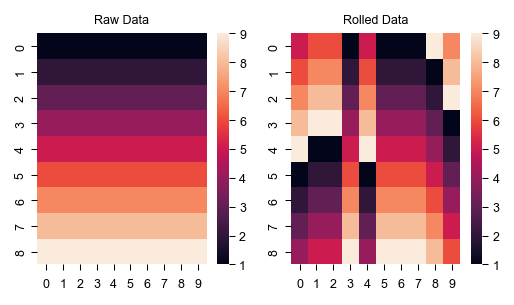

In [75]:
fig, axes = plt.subplots(1, 2, figsize=(4, 2))
sns.heatmap(ax = axes[0], data = mat)
axes[0].set_title('Raw Data')

sns.heatmap(ax = axes[1], data = rolled)
axes[1].set_title('Rolled Data')


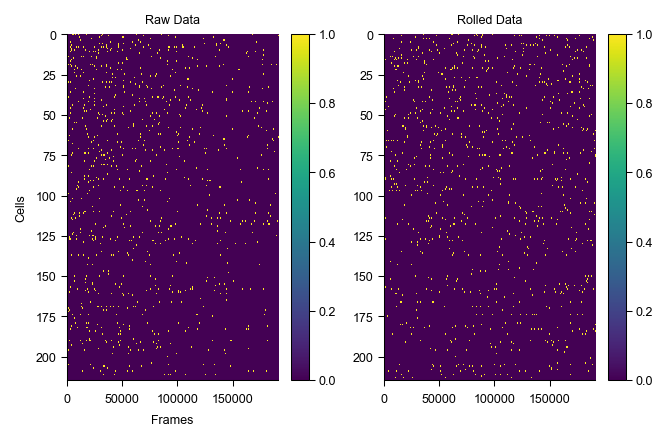

In [76]:
fig, axes = plt.subplots(1, 2, figsize=(5, 3))
# Use imshow instead of seaborn heatmap for large data
im = axes[0].imshow(raster_df[cell_col].values.T, aspect='auto', cmap='viridis', interpolation='nearest')
axes[0].set_title('Raw Data')
axes[0].set_xlabel('Frames')
axes[0].set_ylabel('Cells')
plt.colorbar(im, ax=axes[0])

# For the rolled data
data = raster_df.loc[:, cell_col].values
roll_data = random_roll_columns(data)
im2 = axes[1].imshow(roll_data.T, aspect='auto', cmap='viridis', interpolation='nearest')
axes[1].set_title('Rolled Data')
plt.colorbar(im2, ax=axes[1])


In [77]:
def get_mean_postoutcome_stage_activity(input_df, cell_col, label_col='task_stage', section_col = 'trial_section', post_outcome_label='post_outcome'):
    """ For groupby operation that returns mean activity for post-outcome stage of each cell in each section """
    mean_section_stage_act = input_df.groupby(by = [label_col, section_col])[cell_col].mean() #325 ms
    return mean_section_stage_act.loc[(slice(None),post_outcome_label),:]    

def create_shuffled_df(args):
    """Helper function for parallel processing"""
    df, cell_col, random_seed = args
    roll_data = random_roll_columns(df[cell_col].values, random_seed= random_seed)
    rolled_df = pd.DataFrame(roll_data, columns=cell_col, index=df.index).join(df.drop(columns = cell_col))
    mean_section_stage_act = get_mean_postoutcome_stage_activity(rolled_df, cell_col)
    #new- 11.8.25- add shuffle seed record 
    mean_section_stage_act['shuffle_seed'] = random_seed
    return mean_section_stage_act

# 1s per shuffle is current speed

In [109]:
raster_dataframes

{'10_3_HET_RS1':               cell_1  cell_2  cell_3  cell_4  cell_5  cell_6  cell_7  cell_8  \
 frame_14928        1       0       0       0       0       0       0       1   
 frame_14929        1       0       0       0       0       0       0       1   
 frame_14930        1       0       0       0       0       0       0       1   
 frame_14931        1       0       0       0       0       0       0       1   
 frame_14932        0       0       0       0       0       0       0       1   
 ...              ...     ...     ...     ...     ...     ...     ...     ...   
 frame_150410       0       0       0       0       0       0       0       0   
 frame_150411       0       0       0       0       0       0       0       0   
 frame_150412       0       0       0       0       0       0       0       0   
 frame_150413       0       0       0       0       0       0       0       0   
 frame_150414       0       0       0       0       0       0       0       0   
 
          

In [ ]:
run_shuffles = True  #set to True to run shuffles
# Option 1: Global seed sequence across all subjects
# This ensures no seed overlap between subjects

#16 physical cores to use 
total_cpu_physical = psutil.cpu_count(logical=False)
print(total_cpu_physical)
n_jobs= total_cpu_physical-2

# Configuration
n_shuf_per_subject = 1000
base_seed = 42
n_subjects = len(raster_dataframes)

# Generate global seed sequence
total_shuffles = n_subjects * n_shuf_per_subject
global_seeds = [base_seed + i for i in range(total_shuffles)]

print(f"Total subjects: {n_subjects}")
print(f"Shuffles per subject: {n_shuf_per_subject}")
print(f"Total shuffles: {total_shuffles}")
print(f"Seed range: {global_seeds[0]} to {global_seeds[-1]}")
if run_shuffles:
    # Process each subject with their allocated seed range
    all_subject_shuffles = {}

    for subject_idx, (subject_name, subject_raster_df) in enumerate(raster_dataframes.items()):
        print(f"\nProcessing subject {subject_idx+1}/{n_subjects}: {subject_name}")
        
        # Get cell columns for this subject
        cell_col = [c for c in subject_raster_df.columns if 'cell' in c]
        
        # Allocate unique seed range for this subject
        start_seed_idx = subject_idx * n_shuf_per_subject
        end_seed_idx = start_seed_idx + n_shuf_per_subject
        subject_seeds = global_seeds[start_seed_idx:end_seed_idx]
        
        print(f"  Seed range: {subject_seeds[0]} to {subject_seeds[-1]}")
        print(f"  Cells: {len(cell_col)}, Frames: {len(subject_raster_df)}")
        
        # Run parallel shuffles for this subject- oputputs lists
        output_shuff = Parallel(n_jobs=n_jobs, backend="loky", verbose=3)(
            delayed(create_shuffled_df)((subject_raster_df, cell_col, int(seed))) 
            for seed in subject_seeds)
        #concat and save files 
        all_shuffle_means = pd.concat(output_shuff).drop(0).reset_index('trial_section', drop = True)

        all_shuffle_means['subject_name'] = subject_name #add shuffle names to each df in output_shuff
        all_subject_shuffles[subject_name] = all_shuffle_means
        print(f"  Completed {len(output_shuff)} shuffles")
        

    print(f"\n✓ All {n_subjects} subjects processed with unique seed ranges")


16
Total subjects: 35
Shuffles per subject: 1000
Total shuffles: 35000
Seed range: 42 to 35041


In [79]:
#set shuffle storage data folder
shuffle_storage_folder = Path("dlx56_mPFC_1p_SohalLab/data") / Path(f"shuffled_dfs_{n_shuf_per_subject}_per_subject")
print(f"storing shuffles in {shuffle_storage_folder}")
shuffle_storage_folder.mkdir(parents=True, exist_ok=True)

storing shuffles in dlx56_mPFC_1p_SohalLab\data\shuffled_dfs_1000_per_subject


In [80]:
## save all shuffles as parquet file: 
# import pyarrow

if run_shuffles:
    print(f"Saving shuffled mean activity DataFrames to {shuffle_storage_folder}")
    for subject_name, output_shuff in all_subject_shuffles.items():

        #in case it was skipped last run, save name as col in df before parquet export
        output_shuff['subject_name'] = subject_name
        parquet_path = shuffle_storage_folder / Path(f"{subject_name}_shuffled_mean_activity.parquet")
        output_shuff.to_parquet(parquet_path)   
else: #load all subject name parquets
    #use subject list from raster dataframes
    all_subject_shuffles = {}
    for subject_name in raster_dataframes.keys():
        parquet_path = shuffle_storage_folder / Path(f"{subject_name}_shuffled_mean_activity.parquet")
        if parquet_path.is_file():
            df = pd.read_parquet(parquet_path)
            all_subject_shuffles[subject_name] = df
            print(f"Loaded shuffled data for {subject_name} from {parquet_path}")
        else:
            print(f"Parquet file not found for {subject_name} at {parquet_path}")

Loaded shuffled data for 10_3_HET_RS1 from dlx56_mPFC_1p_SohalLab\data\shuffled_dfs_1000_per_subject\10_3_HET_RS1_shuffled_mean_activity.parquet
Loaded shuffled data for 10_3_HET_RS2 from dlx56_mPFC_1p_SohalLab\data\shuffled_dfs_1000_per_subject\10_3_HET_RS2_shuffled_mean_activity.parquet
Loaded shuffled data for 10_3_HET_RS3 from dlx56_mPFC_1p_SohalLab\data\shuffled_dfs_1000_per_subject\10_3_HET_RS3_shuffled_mean_activity.parquet
Loaded shuffled data for 13_3_HET_RS1 from dlx56_mPFC_1p_SohalLab\data\shuffled_dfs_1000_per_subject\13_3_HET_RS1_shuffled_mean_activity.parquet
Loaded shuffled data for 13_3_HET_RS2 from dlx56_mPFC_1p_SohalLab\data\shuffled_dfs_1000_per_subject\13_3_HET_RS2_shuffled_mean_activity.parquet
Loaded shuffled data for 13_3_HET_RS3 from dlx56_mPFC_1p_SohalLab\data\shuffled_dfs_1000_per_subject\13_3_HET_RS3_shuffled_mean_activity.parquet
Loaded shuffled data for 13_4_WT_RS1 from dlx56_mPFC_1p_SohalLab\data\shuffled_dfs_1000_per_subject\13_4_WT_RS1_shuffled_mean_acti

In [82]:

def get_cell_stage_enrichment(all_shuffle_means, raster_df, cell_col, n_shuf_per_subject):
    ## code for enrichment analysis: 

    #given N shuffles, find the 95th percentile value for each cell at each task stage
    cell_threshold = all_shuffle_means.groupby('task_stage')[cell_col].agg(lambda x: np.percentile(x, 95)) #empirical?

    #get real raster mean activity data (DESPARSIFY if necessary)
    for col in cell_col:
        if isinstance(raster_df[col], pd.SparseDtype):
            raster_df.loc[:, col] = raster_df[col].sparse.to_dense()
    #group real data by trial_section and task_stage
    real_mean_activity = raster_df.groupby(by = ['trial_section', 'task_stage'])[cell_col].mean().loc['post_outcome', (slice(None))].drop(0)

    #get % of shuffle values greater than or equal to real cell activity
    counts_per_cell = []
    for stage, group in all_shuffle_means.groupby("task_stage"):
        # print(f"checking {stage}")
        real_values = real_mean_activity.loc[stage, cell_col] #get % of shuffle greater than or equal to real
        comparison = group[cell_col] >= real_values      # broadcast columnwise
        counts = comparison.sum()                         # count True per cell
        counts.name = stage                               # label this row
        counts_per_cell.append(counts)
    shuf_percentile = pd.DataFrame(counts_per_cell)/n_shuf_per_subject

    #get boolean mask of enriched cells
    enriched_cells = (real_mean_activity > cell_threshold)

    # melt dataframes for joining analysis
    shuf_percentile_long = shuf_percentile.reset_index().melt(id_vars = 'index', var_name = 'cell', value_name = r'percent_shuffle >= real').rename(columns = {'index': 'task_stage'})
    cell_enrich_long = enriched_cells.reset_index().melt(id_vars = 'task_stage', var_name = 'cell', value_name = 'enriched') #cells activity > threshold
    cell_activity_long = real_mean_activity.reset_index().melt(id_vars = 'task_stage', var_name = 'cell', value_name = 'mean') #real mean activity of cells
    cell_thresh_long = cell_threshold.reset_index().melt(id_vars = 'task_stage', var_name = 'cell', value_name = 'percentile_95') #95th percentile of shuffles

    #join dataframes
    cell_ensemble_info = pd.merge(pd.merge(cell_thresh_long, cell_activity_long, on=['task_stage','cell']), cell_enrich_long, on=['task_stage','cell'])
    cell_ensemble_info = pd.merge(cell_ensemble_info, shuf_percentile_long, on=['task_stage','cell'])
    #add subject marker 
    cell_ensemble_info['subject_name'] = raster_df['subject_name'].unique()[0]
    return cell_ensemble_info

In [83]:
# get shuffle data percentiles
concat_cell_ensemble_info = []
for subject_name, all_shuffle_means in all_subject_shuffles.items():
    print(f"Calculating enrichment for {subject_name}")
    raster_df = raster_dataframes[subject_name]
    cell_col = [c for c in raster_df.columns if 'cell' in c]
    cell_ensemble_info = get_cell_stage_enrichment(all_shuffle_means, raster_df, cell_col, n_shuf_per_subject)
    concat_cell_ensemble_info.append(cell_ensemble_info)


Calculating enrichment for 10_3_HET_RS1
Calculating enrichment for 10_3_HET_RS2
Calculating enrichment for 10_3_HET_RS3
Calculating enrichment for 13_3_HET_RS1
Calculating enrichment for 13_3_HET_RS2
Calculating enrichment for 13_3_HET_RS3
Calculating enrichment for 13_4_WT_RS1
Calculating enrichment for 13_4_WT_RS2
Calculating enrichment for 13_5_HET_RS1
Calculating enrichment for 13_5_HET_RS2
Calculating enrichment for 13_5_HET_RS3
Calculating enrichment for 13_6_WT_RS1
Calculating enrichment for 13_6_WT_RS2
Calculating enrichment for 13_8_HET_RS1
Calculating enrichment for 13_8_HET_RS2
Calculating enrichment for 13_8_HET_RS3
Calculating enrichment for 14_2_WT_RS1
Calculating enrichment for 14_2_WT_RS2
Calculating enrichment for 15_1_HET_RS1
Calculating enrichment for 15_1_HET_RS2
Calculating enrichment for 15_1_HET_RS3
Calculating enrichment for 5_3_WT_RS1
Calculating enrichment for 5_3_WT_RS2
Calculating enrichment for 6_2_WT_RS1
Calculating enrichment for 6_2_WT_RS2
Calculating en

In [84]:
all_ensembles = pd.concat(concat_cell_ensemble_info).reset_index(drop = True)
all_ensembles['neuron_id'] = all_ensembles['subject_name'] + '-' + all_ensembles['cell'].str.replace('cell_','')
all_ensembles

,task_stage,cell,percentile_95,mean,enriched,percent_shuffle >= real,subject_name,neuron_id
0,Early_IA_Correct,cell_1,0.101822,0,False,1.0,10_3_HET_RS1,10_3_HET_RS1-1
1,Early_IA_Error,cell_1,0.179688,0,False,1.0,10_3_HET_RS1,10_3_HET_RS1-1
2,Early_RS_Correct,cell_1,0.116187,0,False,1.0,10_3_HET_RS1,10_3_HET_RS1-1
3,Early_RS_Error,cell_1,0.137857,0,False,1.0,10_3_HET_RS1,10_3_HET_RS1-1
4,Late_IA,cell_1,0.089214,0,False,1.0,10_3_HET_RS1,10_3_HET_RS1-1
...,...,...,...,...,...,...,...,...
34674,Early_IA_Error,cell_215,0.019492,0,False,1.0,9_3_HET_RS3,9_3_HET_RS3-215
34675,Early_RS_Correct,cell_215,0.018229,0,False,1.0,9_3_HET_RS3,9_3_HET_RS3-215
34676,Early_RS_Error,cell_215,0.023333,0,False,1.0,9_3_HET_RS3,9_3_HET_RS3-215
34677,Late_IA,cell_215,0.012399,0,False,1.0,9_3_HET_RS3,9_3_HET_RS3-215


In [85]:
ens_matrix = all_ensembles.pivot_table(index = ['neuron_id'], columns = 'task_stage', values = 'enriched', fill_value = False)
ens_matrix

task_stage,Early_IA_Correct,Early_IA_Error,Early_RS_Correct,Early_RS_Error,Late_IA,Late_RS
neuron_id,,,,,,
10_3_HET_RS1-1,False,False,False,False,False,False
10_3_HET_RS1-10,False,False,False,False,False,False
10_3_HET_RS1-100,False,False,False,False,False,False
10_3_HET_RS1-101,False,False,False,False,False,False
10_3_HET_RS1-102,False,False,False,False,False,False
...,...,...,...,...,...,...
9_3_HET_RS3-95,False,False,False,False,False,False
9_3_HET_RS3-96,False,False,False,False,False,False
9_3_HET_RS3-97,False,False,False,False,False,False


In [86]:
ens_matrix.astype(int)

task_stage,Early_IA_Correct,Early_IA_Error,Early_RS_Correct,Early_RS_Error,Late_IA,Late_RS
neuron_id,,,,,,
10_3_HET_RS1-1,0,0,0,0,0,0
10_3_HET_RS1-10,0,0,0,0,0,0
10_3_HET_RS1-100,0,0,0,0,0,0
10_3_HET_RS1-101,0,0,0,0,0,0
10_3_HET_RS1-102,0,0,0,0,0,0
...,...,...,...,...,...,...
9_3_HET_RS3-95,0,0,0,0,0,0
9_3_HET_RS3-96,0,0,0,0,0,0
9_3_HET_RS3-97,0,0,0,0,0,0


In [87]:
pd.merge(ens_matrix, canon_ensembles, left_on = 'neuron_id', right_on = 'unique_ID')

,Early_IA_Correct_x,Early_IA_Error_x,Early_RS_Correct_x,Early_RS_Error_x,Late_IA_x,Late_RS_x,Early_IA_Error_y,Early_IA_Correct_y,Late_IA_y,Early_RS_Error_y,Early_RS_Correct_y,Late_RS_y
0,False,False,False,False,False,False,1.0,0.0,0.0,0.0,0.0,0.0
1,False,False,False,False,False,False,1.0,0.0,0.0,0.0,0.0,0.0
2,False,False,False,False,False,False,0.0,0.0,0.0,0.0,0.0,0.0
3,False,False,False,False,False,False,0.0,0.0,1.0,1.0,0.0,0.0
4,False,False,False,False,False,False,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
4771,False,False,False,False,False,False,0.0,0.0,0.0,0.0,0.0,0.0
4772,False,False,False,False,False,False,0.0,0.0,0.0,0.0,0.0,0.0
4773,False,False,False,False,False,False,1.0,0.0,0.0,0.0,0.0,0.0
4774,False,False,False,False,False,False,0.0,0.0,0.0,0.0,0.0,0.0


#### compare old/canon ensembles and latest ensemble run 


In [88]:
canon_ensembles

,,,Early_IA_Error,Early_IA_Correct,Late_IA,Early_RS_Error,Early_RS_Correct,Late_RS
unique_ID,geno,geno_day,,,,,,
10_3_HET_RS1-1,HET,Het VEH,1.0,0.0,0.0,0.0,0.0,0.0
10_3_HET_RS1-10,HET,Het VEH,1.0,0.0,0.0,0.0,0.0,0.0
10_3_HET_RS1-101,HET,Het VEH,0.0,0.0,0.0,0.0,0.0,0.0
10_3_HET_RS1-104,HET,Het VEH,0.0,0.0,1.0,1.0,0.0,0.0
10_3_HET_RS1-107,HET,Het VEH,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...
9_3_HET_RS3-95,HET,Het postCLNZ,0.0,0.0,0.0,0.0,0.0,0.0
9_3_HET_RS3-96,HET,Het postCLNZ,0.0,0.0,0.0,0.0,0.0,0.0
9_3_HET_RS3-97,HET,Het postCLNZ,1.0,0.0,0.0,0.0,0.0,0.0


In [89]:
canon_ensembles = canon_ensembles.reset_index(level=[1,2])
canon_ensembles

,geno,geno_day,Early_IA_Error,Early_IA_Correct,Late_IA,Early_RS_Error,Early_RS_Correct,Late_RS
unique_ID,,,,,,,,
10_3_HET_RS1-1,HET,Het VEH,1.0,0.0,0.0,0.0,0.0,0.0
10_3_HET_RS1-10,HET,Het VEH,1.0,0.0,0.0,0.0,0.0,0.0
10_3_HET_RS1-101,HET,Het VEH,0.0,0.0,0.0,0.0,0.0,0.0
10_3_HET_RS1-104,HET,Het VEH,0.0,0.0,1.0,1.0,0.0,0.0
10_3_HET_RS1-107,HET,Het VEH,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...
9_3_HET_RS3-95,HET,Het postCLNZ,0.0,0.0,0.0,0.0,0.0,0.0
9_3_HET_RS3-96,HET,Het postCLNZ,0.0,0.0,0.0,0.0,0.0,0.0
9_3_HET_RS3-97,HET,Het postCLNZ,1.0,0.0,0.0,0.0,0.0,0.0


In [101]:
canon_post_taco.set_index('unique_ID')

,Early_IA_Error,Early_IA_Correct,Late_IA,Early_RS_Error,Early_RS_Correct,Late_RS,name,geno_day,geno,neuron_ID
unique_ID,,,,,,,,,,
10_3_HET_RS1-1,1,0,0,0,0,0,10_3_HET_RS1,HET RS1,HET,1
10_3_HET_RS1-2,0,0,0,0,0,0,10_3_HET_RS1,HET RS1,HET,2
10_3_HET_RS1-3,1,0,0,0,0,0,10_3_HET_RS1,HET RS1,HET,3
10_3_HET_RS1-4,0,0,0,1,0,0,10_3_HET_RS1,HET RS1,HET,4
10_3_HET_RS1-5,0,0,0,0,0,0,10_3_HET_RS1,HET RS1,HET,5
...,...,...,...,...,...,...,...,...,...,...
9_3_HET_RS3-211,0,0,0,0,0,0,9_3_HET_RS3,HET RS3,HET,211
9_3_HET_RS3-212,1,0,0,1,0,0,9_3_HET_RS3,HET RS3,HET,212
9_3_HET_RS3-213,0,0,0,0,0,0,9_3_HET_RS3,HET RS3,HET,213


In [102]:
ens_matrix

task_stage,Early_IA_Correct,Early_IA_Error,Early_RS_Correct,Early_RS_Error,Late_IA,Late_RS
neuron_id,,,,,,
10_3_HET_RS1-1,False,False,False,False,False,False
10_3_HET_RS1-10,False,False,False,False,False,False
10_3_HET_RS1-100,False,False,False,False,False,False
10_3_HET_RS1-101,False,False,False,False,False,False
10_3_HET_RS1-102,False,False,False,False,False,False
...,...,...,...,...,...,...
9_3_HET_RS3-95,False,False,False,False,False,False
9_3_HET_RS3-96,False,False,False,False,False,False
9_3_HET_RS3-97,False,False,False,False,False,False


In [106]:
combined_ens = canon_post_taco.set_index('unique_ID').join(ens_matrix.astype(int), how = 'inner', rsuffix = '_new')

combined_ens

,Early_IA_Error,Early_IA_Correct,Late_IA,Early_RS_Error,Early_RS_Correct,Late_RS,name,geno_day,geno,neuron_ID,Early_IA_Correct_new,Early_IA_Error_new,Early_RS_Correct_new,Early_RS_Error_new,Late_IA_new,Late_RS_new
10_3_HET_RS1-1,1,0,0,0,0,0,10_3_HET_RS1,HET RS1,HET,1,0,0,0,0,0,0
10_3_HET_RS1-2,0,0,0,0,0,0,10_3_HET_RS1,HET RS1,HET,2,0,0,0,0,0,0
10_3_HET_RS1-3,1,0,0,0,0,0,10_3_HET_RS1,HET RS1,HET,3,0,0,0,0,0,0
10_3_HET_RS1-4,0,0,0,1,0,0,10_3_HET_RS1,HET RS1,HET,4,0,0,0,0,0,0
10_3_HET_RS1-5,0,0,0,0,0,0,10_3_HET_RS1,HET RS1,HET,5,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9_3_HET_RS3-211,0,0,0,0,0,0,9_3_HET_RS3,HET RS3,HET,211,0,0,0,0,0,0
9_3_HET_RS3-212,1,0,0,1,0,0,9_3_HET_RS3,HET RS3,HET,212,0,0,0,0,0,0
9_3_HET_RS3-213,0,0,0,0,0,0,9_3_HET_RS3,HET RS3,HET,213,0,0,0,0,0,0
9_3_HET_RS3-214,0,0,0,0,0,1,9_3_HET_RS3,HET RS3,HET,214,0,0,0,0,0,0


<Axes: xlabel='task_stage', ylabel='neuron_id'>

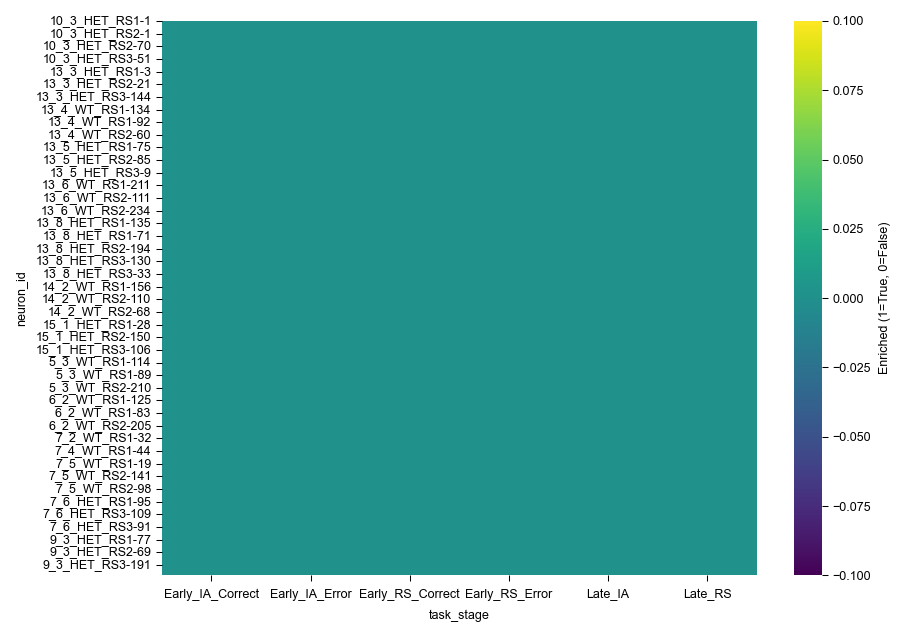

In [108]:
sns.heatmap(ens_matrix.astype(int), cmap = 'viridis', cbar_kws={'label': 'Enriched (1=True, 0=False)'})

In [107]:
df = combined_ens
# Define the stage names
stages = ['Early_IA_Error', 'Early_IA_Correct', 'Late_IA', 
          'Early_RS_Error', 'Early_RS_Correct', 'Late_RS']

# Compute correlation for each stage
correlations = {}
for stage in stages:
    old_col = stage
    new_col = stage + '_new'
    correlation = df[old_col].corr(df[new_col])
    correlations[stage] = correlation

# Display results
corr_df = pd.DataFrame.from_dict(correlations, orient='index', columns=['Correlation'])
print(corr_df)

                  Correlation
Early_IA_Error            NaN
Early_IA_Correct          NaN
Late_IA                   NaN
Early_RS_Error            NaN
Early_RS_Correct          NaN
Late_RS                   NaN


c:\Users\13car\anaconda3\envs\local_colab\Lib\site-packages\numpy\lib\function_base.py:2897: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\13car\anaconda3\envs\local_colab\Lib\site-packages\numpy\lib\function_base.py:2898: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


In [92]:
print(canon_ensembles.columns)
print(ens_matrix.columns)

Index(['geno', 'geno_day', 'Early_IA_Error', 'Early_IA_Correct', 'Late_IA',
       'Early_RS_Error', 'Early_RS_Correct', 'Late_RS'],
      dtype='object')
Index(['Early_IA_Correct', 'Early_IA_Error', 'Early_RS_Correct',
       'Early_RS_Error', 'Late_IA', 'Late_RS'],
      dtype='object', name='task_stage')


In [93]:
ens_matrix

task_stage,Early_IA_Correct,Early_IA_Error,Early_RS_Correct,Early_RS_Error,Late_IA,Late_RS
neuron_id,,,,,,
10_3_HET_RS1-1,False,False,False,False,False,False
10_3_HET_RS1-10,False,False,False,False,False,False
10_3_HET_RS1-100,False,False,False,False,False,False
10_3_HET_RS1-101,False,False,False,False,False,False
10_3_HET_RS1-102,False,False,False,False,False,False
...,...,...,...,...,...,...
9_3_HET_RS3-95,False,False,False,False,False,False
9_3_HET_RS3-96,False,False,False,False,False,False
9_3_HET_RS3-97,False,False,False,False,False,False


In [94]:
canonical_data.loc[:,stage_names+['unique_ID']]

,Early_IA_Error,Early_IA_Correct,Late_IA,Early_RS_Error,Early_RS_Correct,Late_RS,unique_ID
0,1.0,0.0,0.0,0.0,0.0,0.0,10_3_HET_RS1-1
2,1.0,0.0,0.0,0.0,0.0,0.0,10_3_HET_RS1-3
3,0.0,0.0,0.0,1.0,0.0,0.0,10_3_HET_RS1-4
4,0.0,0.0,0.0,0.0,0.0,0.0,10_3_HET_RS1-5
5,0.0,0.0,0.0,0.0,0.0,0.0,10_3_HET_RS1-6
...,...,...,...,...,...,...,...
116370,1.0,0.0,0.0,0.0,0.0,0.0,9_3_HET_RS3-209
116373,1.0,1.0,0.0,0.0,0.0,0.0,9_3_HET_RS3-212
116374,0.0,0.0,0.0,0.0,0.0,0.0,9_3_HET_RS3-213
116375,0.0,0.0,0.0,0.0,0.0,0.0,9_3_HET_RS3-214


#### compare new/old cell count

In [95]:
print(canonical_data.groupby(by = 'geno_day')['unique_ID'].nunique())
print(f" Canon unique cells: {canonical_data['unique_ID'].nunique()}")

geno_day
Het CLNZ         866
Het VEH          874
Het postCLNZ     937
WT CLNZ         1019
WT VEH          1080
Name: unique_ID, dtype: int64
 Canon unique cells: 4776


In [96]:
subject_cell_count_old = canonical_data.groupby(by = 'name')['unique_ID'].nunique()
subject_cell_count_old

name
10_3_HET_RS1     97
10_3_HET_RS2    124
10_3_HET_RS3    122
13_3_HET_RS1    121
13_3_HET_RS2    106
13_3_HET_RS3    126
13_4_WT_RS1     165
13_4_WT_RS2     147
13_5_HET_RS1    114
13_5_HET_RS2    118
13_5_HET_RS3    107
13_6_WT_RS1     210
13_6_WT_RS2     203
13_8_HET_RS1    123
13_8_HET_RS2    135
13_8_HET_RS3    161
14_2_WT_RS1     138
14_2_WT_RS2     142
15_1_HET_RS1    155
15_1_HET_RS2    167
15_1_HET_RS3    108
5_3_WT_RS1      145
5_3_WT_RS2      182
6_2_WT_RS1      136
6_2_WT_RS2      181
7_2_WT_RS1       52
7_4_WT_RS1       80
7_5_WT_RS1      154
7_5_WT_RS2      164
7_6_HET_RS1     125
7_6_HET_RS2     107
7_6_HET_RS3     134
9_3_HET_RS1     139
9_3_HET_RS2     109
9_3_HET_RS3     179
Name: unique_ID, dtype: int64

In [97]:
subject_cell_count_new = all_ensembles.groupby(by = 'subject_name')['neuron_id'].nunique()
subject_cell_count_new

subject_name
10_3_HET_RS1    136
10_3_HET_RS2    168
10_3_HET_RS3    157
13_3_HET_RS1    160
13_3_HET_RS2    145
13_3_HET_RS3    147
13_4_WT_RS1     183
13_4_WT_RS2     171
13_5_HET_RS1    120
13_5_HET_RS2    125
13_5_HET_RS3    131
13_6_WT_RS1     247
13_6_WT_RS2     246
13_8_HET_RS1    207
13_8_HET_RS2    206
13_8_HET_RS3    244
14_2_WT_RS1     186
14_2_WT_RS2     184
15_1_HET_RS1    180
15_1_HET_RS2    185
15_1_HET_RS3    127
5_3_WT_RS1      165
5_3_WT_RS2      231
6_2_WT_RS1      183
6_2_WT_RS2      229
7_2_WT_RS1       91
7_4_WT_RS1      131
7_5_WT_RS1      164
7_5_WT_RS2      185
7_6_HET_RS1     139
7_6_HET_RS2     120
7_6_HET_RS3     156
9_3_HET_RS1     152
9_3_HET_RS2     145
9_3_HET_RS3     215
Name: neuron_id, dtype: int64

In [98]:
all_ensembles
print(f" new unique cells: {all_ensembles['neuron_id'].nunique()}")

 new unique cells: 5961


In [99]:
subj_cell_comp = subject_cell_count_old.to_frame().rename({'unique_ID': 'old_n'},axis = 1).join(
    subject_cell_count_new.to_frame().rename({'neuron_id': 'new_n'},axis = 1), lsuffix = '_old', rsuffix = '_new')

subj_cell_comp

,old_n,new_n
name,,
10_3_HET_RS1,97,136
10_3_HET_RS2,124,168
10_3_HET_RS3,122,157
13_3_HET_RS1,121,160
13_3_HET_RS2,106,145
13_3_HET_RS3,126,147
13_4_WT_RS1,165,183
13_4_WT_RS2,147,171
13_5_HET_RS1,114,120
